# Masked-HWM Full Dataset Training (Kaggle)

Kaggle-ready notebook for training Masked-HWM on the imported `world-model-dataset`. It reads the dataset from `/kaggle/input`, writes checkpoints and generated files to `/kaggle/working`, and avoids Colab/Google Drive paths.


In [3]:
# Main settings
from pathlib import Path

REPO_URL = "https://github.com/qasim-ali0/humanoid_world_model.git"
BRANCH = None

# Kaggle datasets are read-only and mounted under /kaggle/input.
# Leave KAGGLE_DATASET_ROOT as None to auto-detect a folder containing train_v2.0 and val_v2.0.
KAGGLE_INPUT_ROOT = Path("/kaggle/input")
KAGGLE_WORKING_ROOT = Path("/kaggle/working")
KAGGLE_DATASET_ROOT = None

DATASET_ROOT = None
TRAIN_DATA_DIR = None
VAL_DATA_DIR = None

# Leave None to run by epochs. For Kaggle, a bounded first run is usually easier to resume from.
MAX_TRAIN_STEPS = 10000
NUM_TRAIN_EPOCHS = 1
CHECKPOINTING_STEPS = 10000
EVAL_EVERY_N_STEPS = 1000
MAX_EVAL_STEPS = 50

PER_DEVICE_TRAIN_BATCH_SIZE = 1
PER_DEVICE_EVAL_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 1
LEARNING_RATE = 3e-5
NUM_WARMUP_STEPS = 100
WITH_ACT = False
USE_GRADIENT_CHECKPOINTING = False
USE_TORCH_COMPILE = False

LOG_NAME = "cosmos_24_512_full_dataset"
OUTPUT_DIR = str(KAGGLE_WORKING_ROOT / "logs")
CHECKPOINT_EXPORT_DIR = KAGGLE_WORKING_ROOT / "checkpoints"

# Optional: set a Kaggle secret named HF_TOKEN only if you later need Hugging Face downloads.
HF_TOKEN = ""


In [2]:
#Tested only
# MAX_TRAIN_STEPS = 1
# NUM_TRAIN_EPOCHS = 1
# CHECKPOINTING_STEPS = 1
# EVAL_EVERY_N_STEPS = 999999
# MAX_EVAL_STEPS = 1

# PER_DEVICE_TRAIN_BATCH_SIZE = 1
# PER_DEVICE_EVAL_BATCH_SIZE = 1
# GRADIENT_ACCUMULATION_STEPS = 1
# USE_TORCH_COMPILE = False
# USE_GRADIENT_CHECKPOINTING = False

In [4]:
from pathlib import Path
import os
import subprocess
import sys


def run(cmd, cwd=None, check=True, env=None):
    print("\n$", " ".join(map(str, cmd)))
    result = subprocess.run(
        list(map(str, cmd)),
        cwd=cwd,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        env=env,
    )
    print(result.stdout)
    if check and result.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {result.returncode}: {' '.join(map(str, cmd))}")
    return result


def find_kaggle_dataset_root(input_root=KAGGLE_INPUT_ROOT, manual_root=KAGGLE_DATASET_ROOT):
    candidates = []
    if manual_root:
        candidates.append(Path(manual_root))

    input_root = Path(input_root)
    candidates.extend([
        input_root / "world-model-dataset" / "world-model",
        input_root / "datasets" / "lnk135" / "world-model-dataset" / "world-model",
        input_root / "world-model" / "world-model",
        input_root / "world-model",
    ])

    if input_root.exists():
        candidates.extend(p.parent.parent for p in input_root.rglob("train_v2.0/metadata.json"))

    seen = set()
    for candidate in candidates:
        candidate = candidate.expanduser()
        key = str(candidate)
        if key in seen:
            continue
        seen.add(key)
        if (candidate / "train_v2.0" / "metadata.json").exists() and (candidate / "val_v2.0" / "metadata.json").exists():
            return candidate

    checked = "\n".join(f"- {p}" for p in list(dict.fromkeys(map(str, candidates)))[:40])
    raise FileNotFoundError(
        "Could not auto-detect the Kaggle dataset root. Set KAGGLE_DATASET_ROOT to the folder "
        "that contains train_v2.0 and val_v2.0. Checked:\n" + checked
    )


DATASET_DIR = find_kaggle_dataset_root()
TRAIN_DATA_DIR = str(DATASET_DIR / "train_v2.0")
VAL_DATA_DIR = str(DATASET_DIR / "val_v2.0")
print("Dataset root:", DATASET_DIR)
print("Train data dir:", TRAIN_DATA_DIR)
print("Val data dir:", VAL_DATA_DIR)

WORK_ROOT = KAGGLE_WORKING_ROOT if Path("/kaggle/working").exists() else Path.cwd()
WORK_ROOT.mkdir(parents=True, exist_ok=True)
if (WORK_ROOT / "Masked-HWM").exists():
    MASKED_HWM_DIR = WORK_ROOT / "Masked-HWM"
elif (WORK_ROOT / "humanoid_world_model" / "Masked-HWM").exists():
    MASKED_HWM_DIR = WORK_ROOT / "humanoid_world_model" / "Masked-HWM"
elif (Path.cwd() / "train.py").exists() and (Path.cwd() / "genie").exists():
    MASKED_HWM_DIR = Path.cwd()
else:
    repo_dir = WORK_ROOT / "humanoid_world_model"
    clone_cmd = ["git", "clone"]
    if BRANCH:
        clone_cmd += ["--branch", BRANCH]
    clone_cmd += [REPO_URL, str(repo_dir)]
    run(clone_cmd)
    MASKED_HWM_DIR = repo_dir / "Masked-HWM"

os.chdir(MASKED_HWM_DIR)
print("Working directory:", Path.cwd())


Dataset root: /kaggle/input/datasets/lnk135/world-model-dataset/world-model
Train data dir: /kaggle/input/datasets/lnk135/world-model-dataset/world-model/train_v2.0
Val data dir: /kaggle/input/datasets/lnk135/world-model-dataset/world-model/val_v2.0

$ git clone https://github.com/qasim-ali0/humanoid_world_model.git /kaggle/working/humanoid_world_model
Cloning into '/kaggle/working/humanoid_world_model'...
Filtering content:  91% (32/35), 15.42 MiB | 28.80 MiB/s
Filtering content:  94% (33/35), 15.42 MiB | 28.80 MiB/s
Filtering content:  97% (34/35), 15.42 MiB | 28.80 MiB/s
Filtering content: 100% (35/35), 15.42 MiB | 28.80 MiB/s
Filtering content: 100% (35/35), 24.70 MiB | 21.11 MiB/s, done.

Working directory: /kaggle/working/humanoid_world_model/Masked-HWM


In [5]:
# Dependencies for modern Kaggle/Colab runtimes.
run([sys.executable, "-m", "pip", "install", "-U", "pip", "setuptools", "wheel"])

runtime_deps = [
    "accelerate==0.30.1",
    "lpips==0.1.4",
    "matplotlib",
    "transformers==4.41.0",
    "lightning>2.3.1",
    "tqdm==4.66.4",
    "wandb",
    "wheel",
    "packaging",
    "ninja",
    "einops",
    "mup",
]
run([sys.executable, "-m", "pip", "install", *runtime_deps])

xformers_result = run([sys.executable, "-m", "pip", "install", "xformers"], check=False)
print("xformers install return code:", xformers_result.returncode)

run([sys.executable, "-m", "pip", "install", "-e", "."])

import torch
print("python:", sys.version)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())



$ /usr/bin/python3 -m pip install -U pip setuptools wheel
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 53.8 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.46.3
    Uninstalling wheel-0.46.3:
      Successfully uninstalled wheel-0.46.3
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.6 which is incompatible.
torch 2.10.0+cu128 requires cuda-bindings==12.9.4;

In [6]:
# Load HF_TOKEN from Kaggle secrets when available. The imported Kaggle dataset does not require it.
if not HF_TOKEN:
    try:
        from kaggle_secrets import UserSecretsClient
        HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
        print("Loaded HF_TOKEN from Kaggle secrets")
    except Exception:
        pass

if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
else:
    print("No HF_TOKEN configured; continuing with the imported Kaggle dataset.")


No HF_TOKEN configured; continuing with the imported Kaggle dataset.


In [7]:
# Runtime compatibility patches.
from pathlib import Path

attention_path = Path("genie/attention.py")
text = attention_path.read_text()
old_import = "from xformers.ops import LowerTriangularMask, memory_efficient_attention, unbind"
new_import = '''try:
    from xformers.ops import LowerTriangularMask, memory_efficient_attention, unbind
    _XFORMERS_IMPORT_ERROR = None
except Exception as exc:
    LowerTriangularMask = memory_efficient_attention = unbind = None
    _XFORMERS_IMPORT_ERROR = exc'''
if old_import in text:
    text = text.replace(old_import, new_import)

old_flag = 'XFORMERS_DISABLED = os.environ.get("XFORMERS_DISABLED", "false").lower() == "true"'
new_flag = 'XFORMERS_DISABLED = os.environ.get("XFORMERS_DISABLED", "false").lower() == "true" or _XFORMERS_IMPORT_ERROR is not None'
if old_flag in text:
    text = text.replace(old_flag, new_flag)
attention_path.write_text(text)

transformer_path = Path("genie/st_transformer.py")
text = transformer_path.read_text()
text = text.replace(
    "blocks.append(STBlockBase(num_heads=num_heads,",
    "blocks.append((STBlockBase if with_act else STBlock)(num_heads=num_heads,",
)
text = text.replace(
    "                # x, act = layer(x, act)\n                x = layer(x, act)",
    "                x, act = layer(x, act)",
)
transformer_path.write_text(text)

print("Patched attention fallback and action/no-action transformer selection.")

# Avoid a duplicate full-state final checkpoint when the last step checkpoint already exists.
# Kaggle can fail while writing the second optimizer.bin even though training has finished.
train_path = Path("train.py")
text = train_path.read_text()
old_final_save = "    accelerator.end_training()\n    save_checkpoint(model, accelerator, args, f\"final_checkpt\")\n"
new_final_save = "    accelerator.end_training()\n    last_step_checkpoint = os.path.join(args.output_dir, f\"step_{completed_steps}\")\n    if os.path.isdir(last_step_checkpoint):\n        logger.info(f\"Skipping final_checkpt because {last_step_checkpoint} already exists.\")\n    else:\n        save_checkpoint(model, accelerator, args, f\"final_checkpt\")\n"
if old_final_save in text:
    text = text.replace(old_final_save, new_final_save)
    train_path.write_text(text)
    print("Patched train.py to skip duplicate final_checkpt when last step checkpoint exists.")
else:
    print("train.py final checkpoint skip patch already present or target block not found.")


Patched attention fallback and action/no-action transformer selection.
Patched train.py to skip duplicate final_checkpt when last step checkpoint exists.


In [8]:
# Patch RawTokenDataset to avoid materializing the full train split into RAM.
from pathlib import Path

data_path = Path("data.py")
text = data_path.read_text()
start = text.index("class RawTokenDataset")
end = text.index("def get_maskgit_collator", start)

lazy_class = r'''class RawTokenDataset(TorchDataset):
    def __init__(
        self,
        data_dir,
        is_eval=False,
        window_size=17,
        stride=1,
        filter_overlaps=False,
        with_act=False,
    ):
        self.data_dir = Path(data_dir)
        self.metadata = json.load(open(self.data_dir / "metadata.json"))
        self.num_ranks = self.metadata["num_shards"]
        self.window_size = window_size
        self.stride = stride
        self.filter_overlaps = filter_overlaps
        self.with_act = with_act
        self.is_eval = is_eval

        self.metadata_shards = []
        self.data_list = []
        self.action_list = []
        self.valid_start_inds = []

        for rank in tqdm(range(self.num_ranks)):
            if is_eval:
                meta_path = self.data_dir / f"metadata_{rank}.json"
                vid_filename = self.data_dir / f"video_{rank}.bin"
                act_filename = self.data_dir / f"states_{rank}.bin"
                segment_idx_filename = self.data_dir / f"segment_idx_{rank}.bin"
            else:
                meta_path = self.data_dir / "metadata" / f"metadata_{rank}.json"
                vid_filename = self.data_dir / "videos" / f"video_{rank}.bin"
                act_filename = self.data_dir / "robot_states" / f"states_{rank}.bin"
                segment_idx_filename = self.data_dir / "segment_indices" / f"segment_idx_{rank}.bin"

            shard_meta = json.load(open(meta_path))
            self.metadata_shards.append(shard_meta)
            total_frames = shard_meta["shard_num_frames"]
            num_video_chunks = math.ceil(total_frames / window_size)

            vid = np.memmap(vid_filename, dtype=np.int32, mode="r", shape=(num_video_chunks, 3, 32, 32))
            if total_frames % window_size != 0:
                vid = vid[:-1]

            segment_ids = np.memmap(segment_idx_filename, dtype=np.int32, mode="r", shape=(total_frames,))

            act = None
            if with_act:
                act = np.memmap(act_filename, dtype=np.float32, mode="r", shape=(total_frames, 25))
                if total_frames % window_size != 0:
                    act = act[: (total_frames // window_size) * window_size]

            self.data_list.append(vid)
            self.action_list.append(act)

            num_chunks = len(vid) - 1
            for i in range(num_chunks):
                idx1 = i * window_size
                idx2 = (i + 1) * window_size - 1
                if idx2 < len(segment_ids) and segment_ids[idx1] == segment_ids[idx2]:
                    self.valid_start_inds.append((rank, i))

        if with_act:
            self.action_mean = None
            self.action_std = None

    def __len__(self):
        return len(self.valid_start_inds)

    def __getitem__(self, idx):
        rank, chunk_idx = self.valid_start_inds[idx]
        data = np.asarray(self.data_list[rank][chunk_idx], dtype=np.int32)
        x = torch.from_numpy(data.copy()).flatten()
        attention_mask = torch.ones_like(x)

        actions = None
        if self.with_act:
            start = chunk_idx * self.window_size
            actions = np.asarray(self.action_list[rank][start:start + self.window_size], dtype=np.float32)
            actions = torch.from_numpy(actions.copy())

        return {
            "input_ids": x,
            "labels": x,
            "attention_mask": attention_mask,
            "actions": actions,
        }

'''

data_path.write_text(text[:start] + lazy_class + "\n\n" + text[end:])
print("Patched lazy RawTokenDataset in", data_path)


Patched lazy RawTokenDataset in data.py


In [9]:
# Verify the imported Kaggle dataset. No download is needed.
train_dir = Path(TRAIN_DATA_DIR)
val_dir = Path(VAL_DATA_DIR)
missing = [p for p in [train_dir / "metadata.json", val_dir / "metadata.json"] if not p.exists()]
if missing:
    raise FileNotFoundError("Missing expected dataset metadata: " + ", ".join(map(str, missing)))

print("Dataset already present:", train_dir, val_dir)
print("Visible dataset folders:")
for p in sorted(DATASET_DIR.glob("*"))[:30]:
    print("-", p)


Dataset already present: /kaggle/input/datasets/lnk135/world-model-dataset/world-model/train_v2.0 /kaggle/input/datasets/lnk135/world-model-dataset/world-model/val_v2.0
Visible dataset folders:
- /kaggle/input/datasets/lnk135/world-model-dataset/world-model/.gitattributes
- /kaggle/input/datasets/lnk135/world-model-dataset/world-model/README.md
- /kaggle/input/datasets/lnk135/world-model-dataset/world-model/checkpoint
- /kaggle/input/datasets/lnk135/world-model-dataset/world-model/cosmos_video_decoder.py
- /kaggle/input/datasets/lnk135/world-model-dataset/world-model/magvit2.ckpt
- /kaggle/input/datasets/lnk135/world-model-dataset/world-model/test_v2.0
- /kaggle/input/datasets/lnk135/world-model-dataset/world-model/train_v1.1
- /kaggle/input/datasets/lnk135/world-model-dataset/world-model/train_v2.0
- /kaggle/input/datasets/lnk135/world-model-dataset/world-model/unpack_data_test.py
- /kaggle/input/datasets/lnk135/world-model-dataset/world-model/unpack_data_train_val.py
- /kaggle/input/

In [10]:
# Create the full-data config. The v2.0 shards expose 3 latent frames per sample.
import json

FULL_CONFIG = "genie/configs/cosmos_24_512_t3_prompt1.json"
base_cfg = json.loads(Path("genie/configs/cosmos_24_512.json").read_text())
base_cfg["T"] = 3
base_cfg["num_prompt_frames"] = 1
Path(FULL_CONFIG).write_text(json.dumps(base_cfg, indent=2))
print("Wrote", FULL_CONFIG)
print(base_cfg)


Wrote genie/configs/cosmos_24_512_t3_prompt1.json
{'num_layers': 24, 'num_heads': 8, 'd_model': 512, 'T': 3, 'S': 1024, 'image_vocab_size': 64000, 'use_mup': False, 'num_factored_vocabs': 1, 'qkv_bias': False, 'proj_bias': True, 'attn_drop': 0.0, 'qk_norm': False, 'mlp_ratio': 4.0, 'mlp_drop': 0.4, 'mlp_bias': True, 'num_prompt_frames': 1}


In [11]:
# Sanity-check the real dataset and one collated batch before training.
from data import RawTokenDataset, get_maskgit_collator
from genie.config import GenieConfig

cfg = GenieConfig.from_pretrained(FULL_CONFIG)
cfg.with_act = WITH_ACT
train_ds = RawTokenDataset(TRAIN_DATA_DIR, window_size=17, stride=15, with_act=WITH_ACT)
val_ds = RawTokenDataset(VAL_DATA_DIR, is_eval=True, window_size=17, stride=15, filter_overlaps=True, with_act=WITH_ACT)

print("train examples:", len(train_ds))
print("val examples:", len(val_ds))

sample = train_ds[0]
print("sample input_ids shape:", tuple(sample["input_ids"].shape))
print("sample token range:", int(sample["input_ids"].min()), int(sample["input_ids"].max()))

batch = get_maskgit_collator(cfg)([train_ds[0]])
print("batch input_ids shape:", tuple(batch["input_ids"].shape))
print("batch labels shape:", tuple(batch["labels"].shape))
print("masked tokens:", int((batch["input_ids"] == cfg.image_vocab_size).sum()))
assert batch["input_ids"].shape[-1] == cfg.T * cfg.S
assert cfg.num_prompt_frames < cfg.T
assert int((batch["input_ids"] == cfg.image_vocab_size).sum()) > 0


100%|██████████| 1/1 [00:00<00:00, 74.38it/s]


train examples: 636775
val examples: 2698
sample input_ids shape: (3072,)
sample token range: 124 63843
batch input_ids shape: (1, 3072)
batch labels shape: (1, 3072)
masked tokens: 581


In [26]:
# Train on the real dataset.
os.environ["WANDB_MODE"] = "disabled"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ.setdefault("XFORMERS_DISABLED", "true")

train_cmd = [
    sys.executable, "train.py",
    "--genie_config", FULL_CONFIG,
    "--train_data_dir", TRAIN_DATA_DIR,
    "--val_data_dir", VAL_DATA_DIR,
    "--log_name", LOG_NAME,
    "--output_dir", OUTPUT_DIR,
    "--max_eval_steps", str(MAX_EVAL_STEPS),
    "--seed", "5",
    "--eval_every_n_steps", str(EVAL_EVERY_N_STEPS),
    "--vis_every_n_steps", "999999",
    "--checkpointing_steps", str(CHECKPOINTING_STEPS),
    "--per_device_train_batch_size", str(PER_DEVICE_TRAIN_BATCH_SIZE),
    "--per_device_eval_batch_size", str(PER_DEVICE_EVAL_BATCH_SIZE),
    "--gradient_accumulation_steps", str(GRADIENT_ACCUMULATION_STEPS),
    "--learning_rate", str(LEARNING_RATE),
    "--num_warmup_steps", str(NUM_WARMUP_STEPS),
    "--num_train_epochs", str(NUM_TRAIN_EPOCHS),
]

if MAX_TRAIN_STEPS is not None:
    train_cmd += ["--max_train_steps", str(MAX_TRAIN_STEPS)]
if WITH_ACT:
    train_cmd += ["--with_act"]
if USE_GRADIENT_CHECKPOINTING:
    train_cmd += ["--gradient_checkpointing"]
if not USE_TORCH_COMPILE:
    train_cmd += ["--no_compile"]

run(train_cmd)



$ /usr/bin/python3 train.py --genie_config genie/configs/cosmos_24_512_t3_prompt1.json --train_data_dir /kaggle/input/datasets/lnk135/world-model-dataset/world-model/train_v2.0 --val_data_dir /kaggle/input/datasets/lnk135/world-model-dataset/world-model/val_v2.0 --log_name cosmos_24_512_full_dataset --output_dir /kaggle/working/logs --max_eval_steps 50 --seed 5 --eval_every_n_steps 1000 --vis_every_n_steps 999999 --checkpointing_steps 10000 --per_device_train_batch_size 1 --per_device_eval_batch_size 1 --gradient_accumulation_steps 1 --learning_rate 3e-05 --num_warmup_steps 100 --num_train_epochs 1 --max_train_steps 10000 --no_compile
2026-06-02 14:36:47.981247: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780411008.225141     288 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one

RuntimeError: Command failed with exit code 1: /usr/bin/python3 train.py --genie_config genie/configs/cosmos_24_512_t3_prompt1.json --train_data_dir /kaggle/input/datasets/lnk135/world-model-dataset/world-model/train_v2.0 --val_data_dir /kaggle/input/datasets/lnk135/world-model-dataset/world-model/val_v2.0 --log_name cosmos_24_512_full_dataset --output_dir /kaggle/working/logs --max_eval_steps 50 --seed 5 --eval_every_n_steps 1000 --vis_every_n_steps 999999 --checkpointing_steps 10000 --per_device_train_batch_size 1 --per_device_eval_batch_size 1 --gradient_accumulation_steps 1 --learning_rate 3e-05 --num_warmup_steps 100 --num_train_epochs 1 --max_train_steps 10000 --no_compile

In [12]:
# Save the latest complete checkpoint zip to Kaggle working output.
from pathlib import Path
import shutil

LOG_DIR = Path(OUTPUT_DIR)
SAVE_DIR = Path(CHECKPOINT_EXPORT_DIR)
REQUIRED_CHECKPOINT_FILES = ["model.safetensors", "config.json", "optimizer.bin", "scheduler.bin", "scaler.pt"]

run_folders = sorted(LOG_DIR.glob("cosmos_*"), key=lambda p: p.stat().st_mtime)
if not run_folders:
    raise FileNotFoundError(f"No run folders found in {LOG_DIR}")

latest_run = run_folders[-1]
print(f"Latest run: {latest_run}")

all_ckpts = [p for p in latest_run.iterdir() if p.is_dir()]
complete_ckpts = []
partial_ckpts = []
for ckpt in all_ckpts:
    missing = [name for name in REQUIRED_CHECKPOINT_FILES if not (ckpt / name).exists()]
    if missing:
        partial_ckpts.append((ckpt, missing))
    else:
        complete_ckpts.append(ckpt)

if partial_ckpts:
    print("Skipping partial checkpoints:")
    for ckpt, missing in partial_ckpts:
        print(f"- {ckpt.name}: missing {missing}")

if not complete_ckpts:
    raise FileNotFoundError("No complete checkpoint directories found.")

# Prefer final_checkpt only if complete; otherwise use the newest complete step checkpoint.
checkpoint_dir = sorted(
    complete_ckpts,
    key=lambda p: (0 if p.name == "final_checkpt" else 1, -p.stat().st_mtime),
)[0]
print(f"Using checkpoint: {checkpoint_dir}")

SAVE_DIR.mkdir(parents=True, exist_ok=True)
zip_base = SAVE_DIR / f"{latest_run.name}__{checkpoint_dir.name}"
print(f"Zipping to {zip_base}.zip ...")
archive_path = shutil.make_archive(str(zip_base), "zip", root_dir=checkpoint_dir)
print(f"Saved checkpoint zip: {archive_path}")
print(f"Size: {Path(archive_path).stat().st_size / 1e6:.1f} MB")


FileNotFoundError: No run folders found in /kaggle/working/logs

## Run Inference From Saved Kaggle Checkpoint

Run the cell below after the checkpoint zip has been saved to `/kaggle/working/checkpoints`. It loads the saved model, takes an input sample directly from the imported Kaggle dataset by default, generates the future latent frames, decodes both the input and prediction, then displays the resulting GIFs and comparison image.


In [13]:
# Load checkpoint/model once for inference.
# Rerun this only when you change CHECKPOINT_DIR or restart the Kaggle session.
from pathlib import Path
import json
import math
import os
import sys
import subprocess
import importlib

import numpy as np
import torch
from IPython.display import Image as IPyImage, display
import matplotlib.pyplot as plt

# ---- User-tweakable checkpoint settings ----
KAGGLE_DATA_ROOT = DATASET_DIR
KAGGLE_CHECKPOINT_INPUT_ROOT = Path("/kaggle/input/hw-model-2")
KAGGLE_COSMOS_INPUT_ROOT = Path("/kaggle/input/hw-model-2")
CHECKPOINT_DIR = None  # Leave None to auto-detect an unzipped checkpoint containing model.safetensors + config.json.
FPS = 2
# -------------------------------------------


def find_uploaded_checkpoint_dir(root=KAGGLE_CHECKPOINT_INPUT_ROOT, manual_dir=CHECKPOINT_DIR):
    candidates = []
    if manual_dir:
        candidates.append(Path(manual_dir))

    root = Path(root)
    if root.exists():
        candidates.extend(p.parent for p in root.rglob("model.safetensors"))

    # Fallback for a different Kaggle dataset slug if the input name changes.
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists() and root != kaggle_input:
        candidates.extend(p.parent for p in kaggle_input.rglob("model.safetensors"))

    seen = set()
    for candidate in candidates:
        candidate = candidate.expanduser()
        key = str(candidate.resolve()) if candidate.exists() else str(candidate)
        if key in seen:
            continue
        seen.add(key)
        if (candidate / "model.safetensors").exists() and (candidate / "config.json").exists():
            return candidate

    checked = "\n".join(f"- {c}" for c in candidates[:40])
    raise FileNotFoundError(
        "Could not find an unzipped checkpoint directory with model.safetensors and config.json. "
        "Set CHECKPOINT_DIR manually, for example: "
        "Path('/kaggle/input/hw-model-2/cosmos_24_512_full_dataset-06-01-16-41_...').\n"
        "Checked:\n" + checked
    )


# Find and enter the Masked-HWM repo directory, even if this cell is run from a fresh notebook cwd.
repo_candidates = [
    Path.cwd(),
    Path("/kaggle/working/humanoid_world_model/Masked-HWM"),
]
repo_dir = None
for candidate in repo_candidates:
    if (candidate / "train.py").exists() and (candidate / "genie").exists():
        repo_dir = candidate
        break
if repo_dir is None:
    raise FileNotFoundError(
        "Could not find the Masked-HWM repo directory. Run the notebook setup cells first, "
        "or update repo_candidates in this inference setup cell."
    )
os.chdir(repo_dir)
print("Working directory:", Path.cwd())

CHECKPOINT_DIR = find_uploaded_checkpoint_dir()
print("Checkpoint dir:", CHECKPOINT_DIR.resolve())
print("Checkpoint files:", sorted(p.name for p in CHECKPOINT_DIR.iterdir())[:12])

# Imports that depend on being inside the repo.
from genie.st_mask_git import STMaskGIT
from visualize import decode_latents_wrapper, export_to_gif

# Load model only if it is not already loaded from this checkpoint.
device = "cuda" if torch.cuda.is_available() else "cpu"
checkpoint_key = str(CHECKPOINT_DIR.resolve())
if globals().get("_LOADED_CHECKPOINT_DIR") == checkpoint_key and "model" in globals():
    print("Model already loaded from this checkpoint; reusing it.")
else:
    model = STMaskGIT.from_pretrained(str(CHECKPOINT_DIR)).to(device)
    model.eval()
    _LOADED_CHECKPOINT_DIR = checkpoint_key
    print("Loaded model.")

cfg = model.config
latent_side = math.isqrt(cfg.S)
print(f"Device: {device}")
print(f"Model config: T={cfg.T}, S={cfg.S}, side={latent_side}, num_prompt_frames={cfg.num_prompt_frames}")

# Load the visual tokenizer decoder once too.
# The 1x/worldmodel tokens are Cosmos DV8x8x8 tokens. Use decoder.jit when available.
from PIL import Image


def find_cosmos_decoder_path():
    candidates = [
        # New uploaded Kaggle dataset input.
        KAGGLE_COSMOS_INPUT_ROOT / "decoder.jit",
        KAGGLE_COSMOS_INPUT_ROOT / "Cosmos-0.1-Tokenizer-DV8x8x8" / "decoder.jit",
        KAGGLE_COSMOS_INPUT_ROOT / "Cosmos-0.1-Tokenizer-DV8?8?8" / "decoder.jit",
        # Repo/local fallbacks.
        Path("pretrained_ckpts/Cosmos-0.1-Tokenizer-DV8x8x8/decoder.jit"),
        Path("pretrained_ckpts/Cosmos-0.1-Tokenizer-DV8?8?8/decoder.jit"),
        KAGGLE_DATA_ROOT / "decoder.jit",
        KAGGLE_DATA_ROOT / "Cosmos-0.1-Tokenizer-DV8x8x8" / "decoder.jit",
        KAGGLE_DATA_ROOT / "Cosmos-0.1-Tokenizer-DV8?8?8" / "decoder.jit",
    ]
    for root in [KAGGLE_COSMOS_INPUT_ROOT, Path("/kaggle/input"), Path.cwd()]:
        if root.exists():
            candidates.extend(root.rglob("decoder.jit"))

    seen = set()
    for candidate in candidates:
        key = str(candidate)
        if key in seen:
            continue
        seen.add(key)
        if candidate.exists():
            return candidate
    return None


def tensor_video_to_pil_frames(video):
    video = video.detach().float().cpu()
    if video.ndim == 5:
        video = video[0]
    if video.ndim == 4 and video.shape[0] in (1, 3):
        video = video.permute(1, 2, 3, 0)
    elif video.ndim == 4 and video.shape[-1] in (1, 3):
        pass
    else:
        raise ValueError(f"Unexpected decoded video shape: {tuple(video.shape)}")

    if video.min() < 0:
        video = (video + 1) / 2
    elif video.max() > 1:
        video = video / 255
    video = torch.clamp(video, 0, 1)
    video = (video * 255).to(torch.uint8).numpy()
    return [Image.fromarray(frame) for frame in video]


def import_cosmos_tokenizer_from_source(source_root):
    source_root = Path(source_root)
    if str(source_root) not in sys.path:
        sys.path.insert(0, str(source_root))
    importlib.invalidate_caches()
    from cosmos_tokenizer.video_lib import CausalVideoTokenizer
    return CausalVideoTokenizer


def find_cosmos_tokenizer_source_roots(*roots):
    source_roots = []
    for root in roots:
        root = Path(root)
        if not root.exists():
            continue
        for package_file in root.rglob("cosmos_tokenizer/video_lib.py"):
            source_roots.append(package_file.parents[1])
    return source_roots


def ensure_cosmos_tokenizer_package():
    try:
        from cosmos_tokenizer.video_lib import CausalVideoTokenizer
        return CausalVideoTokenizer
    except ModuleNotFoundError:
        pass

    # Prefer source code already present in Kaggle inputs/working dir.
    for source_root in find_cosmos_tokenizer_source_roots(KAGGLE_COSMOS_INPUT_ROOT, Path("/kaggle/input"), Path("/kaggle/working")):
        try:
            CausalVideoTokenizer = import_cosmos_tokenizer_from_source(source_root)
            print("Using Cosmos-Tokenizer source from:", source_root)
            return CausalVideoTokenizer
        except ModuleNotFoundError:
            continue

    # Install the Cosmos-Tokenizer package/code into Kaggle working.
    cosmos_repo = Path("/kaggle/working/Cosmos-Tokenizer")
    if not cosmos_repo.exists():
        print("cosmos_tokenizer package is missing; cloning NVIDIA/Cosmos-Tokenizer...")
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/NVIDIA/Cosmos-Tokenizer.git", str(cosmos_repo)],
            check=True,
        )

    # Add source path directly first; this avoids needing a kernel restart after pip install.
    for source_root in find_cosmos_tokenizer_source_roots(cosmos_repo):
        try:
            CausalVideoTokenizer = import_cosmos_tokenizer_from_source(source_root)
            print("Using Cosmos-Tokenizer source from:", source_root)
            return CausalVideoTokenizer
        except ModuleNotFoundError:
            continue

    print("Installing Cosmos-Tokenizer package...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-e", str(cosmos_repo)], check=True)
    importlib.invalidate_caches()

    # Try both normal import and explicit source-root import after installation.
    try:
        from cosmos_tokenizer.video_lib import CausalVideoTokenizer
        return CausalVideoTokenizer
    except ModuleNotFoundError:
        for source_root in find_cosmos_tokenizer_source_roots(cosmos_repo):
            CausalVideoTokenizer = import_cosmos_tokenizer_from_source(source_root)
            print("Using Cosmos-Tokenizer source from:", source_root)
            return CausalVideoTokenizer
        raise


cosmos_decoder_path = find_cosmos_decoder_path()
if cosmos_decoder_path is not None:
    try:
        CausalVideoTokenizer = ensure_cosmos_tokenizer_package()
        decoder_key = str(cosmos_decoder_path.resolve())
        if globals().get("_LOADED_COSMOS_DECODER") == decoder_key and "cosmos_decoder" in globals():
            print("Cosmos decoder already loaded; reusing it.")
        else:
            cosmos_decoder = CausalVideoTokenizer(checkpoint_dec=decoder_key)
            _LOADED_COSMOS_DECODER = decoder_key
            print("Loaded Cosmos decoder:", decoder_key)
        DECODER_KIND = "cosmos"
    except Exception as exc:
        print("Could not load Cosmos decoder, falling back to magvit2 decoder:", repr(exc))
        DECODER_KIND = "magvit2"
else:
    print("No decoder.jit found. Falling back to magvit2 decoder; decoded prompts may look wrong for Cosmos tokens.")
    DECODER_KIND = "magvit2"

if DECODER_KIND == "magvit2":
    tokenizer_ckpt = KAGGLE_DATA_ROOT / "magvit2.ckpt"
    if not tokenizer_ckpt.exists():
        raise FileNotFoundError(
            f"No Cosmos decoder.jit found and magvit2 fallback checkpoint is missing: {tokenizer_ckpt}"
        )
    if globals().get("_LOADED_TOKENIZER_CKPT") == str(tokenizer_ckpt.resolve()) and "decode_latents" in globals():
        print("MagVIT tokenizer decoder already loaded; reusing it.")
    else:
        decode_latents = decode_latents_wrapper(
            batch_size=8,
            tokenizer_ckpt=str(tokenizer_ckpt),
            max_images=None,
            device=device,
        )
        _LOADED_TOKENIZER_CKPT = str(tokenizer_ckpt.resolve())
        print("Loaded MagVIT tokenizer decoder.")


def decode_token_video(tokens_THW):
    if DECODER_KIND == "cosmos":
        indices = torch.as_tensor(tokens_THW, dtype=torch.long, device=device).unsqueeze(0)
        decoded = cosmos_decoder.decode(indices)
        return tensor_video_to_pil_frames(decoded)
    return decode_latents(np.asarray(tokens_THW))


def load_one_token_sample(data_dir, split, requested_index, dataset_window_size=17):
    data_dir = Path(data_dir)
    metadata = json.loads((data_dir / "metadata.json").read_text())
    num_shards = metadata["num_shards"]
    seen = 0

    for rank in range(num_shards):
        if split == "val":
            shard_meta_path = data_dir / f"metadata_{rank}.json"
            video_path = data_dir / f"video_{rank}.bin"
            segment_path = data_dir / f"segment_idx_{rank}.bin"
        else:
            shard_meta_path = data_dir / "metadata" / f"metadata_{rank}.json"
            video_path = data_dir / "videos" / f"video_{rank}.bin"
            segment_path = data_dir / "segment_indices" / f"segment_idx_{rank}.bin"

        shard_meta = json.loads(shard_meta_path.read_text())
        total_frames = shard_meta["shard_num_frames"]
        num_video_chunks = math.ceil(total_frames / dataset_window_size)
        effective_chunks = num_video_chunks - (1 if total_frames % dataset_window_size != 0 else 0)
        if effective_chunks <= 1:
            continue

        video_tokens = np.memmap(video_path, dtype=np.int32, mode="r", shape=(num_video_chunks, cfg.T, latent_side, latent_side))
        segment_ids = np.memmap(segment_path, dtype=np.int32, mode="r", shape=(total_frames,))

        for chunk_idx in range(effective_chunks - 1):
            idx1 = chunk_idx * dataset_window_size
            idx2 = (chunk_idx + 1) * dataset_window_size - 1
            if idx2 < len(segment_ids) and segment_ids[idx1] == segment_ids[idx2]:
                if seen == requested_index:
                    return torch.from_numpy(np.asarray(video_tokens[chunk_idx]).copy()).flatten(), seen
                seen += 1

    if seen == 0:
        raise RuntimeError(f"No valid examples found in {data_dir}")

    print(f"Requested example {requested_index}, but only found {seen}. Using the last valid example instead.")
    return load_one_token_sample(data_dir, split, seen - 1, dataset_window_size=dataset_window_size)


def run_masked_hwm_inference(
    example_index=0,
    split="val",
    maskgit_steps=8,
    temperature=0.0,
    dataset_window_size=17,
    fps=FPS,
):
    split = split.lower()
    if split == "train":
        data_dir = KAGGLE_DATA_ROOT / "train_v2.0"
    elif split == "val":
        data_dir = KAGGLE_DATA_ROOT / "val_v2.0"
    else:
        raise ValueError("split must be 'train' or 'val'.")

    sample, actual_index = load_one_token_sample(data_dir, split, example_index, dataset_window_size=dataset_window_size)
    example_THW = sample.reshape(1, cfg.T, latent_side, latent_side).long().to(device)
    print(f"Using {split} example index {actual_index} from {data_dir}")

    prompt_frames = cfg.num_prompt_frames
    prompt_THW = example_THW.clone()
    prompt_THW[:, prompt_frames:] = model.mask_token_id

    predicted_frames = []
    with torch.no_grad():
        for timestep in range(prompt_frames, cfg.T):
            pred_HW, _ = model.maskgit_generate(
                prompt_THW,
                out_t=timestep,
                maskgit_steps=maskgit_steps,
                temperature=temperature,
            )
            predicted_frames.append(pred_HW)
            prompt_THW[:, timestep] = pred_HW

    pred_THW = torch.cat(
        [example_THW[:, :prompt_frames], torch.stack(predicted_frames, dim=1)],
        dim=1,
    )

    input_frames = decode_token_video(example_THW[0].detach().cpu().numpy())
    prediction_frames = decode_token_video(pred_THW[0].detach().cpu().numpy())

    out_dir = Path(KAGGLE_WORKING_ROOT) / "outputs" / "kaggle_checkpoint_inference"
    out_dir.mkdir(parents=True, exist_ok=True)
    input_gif = out_dir / f"input_{split}_example{actual_index}.gif"
    pred_gif = out_dir / f"prediction_{split}_example{actual_index}.gif"
    comparison_png = out_dir / f"comparison_{split}_example{actual_index}.png"

    export_to_gif(input_frames, str(input_gif), fps=fps)
    export_to_gif(prediction_frames, str(pred_gif), fps=fps)

    num_preview_frames = min(len(input_frames), len(prediction_frames), 6)
    preview_indices = np.linspace(0, len(input_frames) - 1, num_preview_frames, dtype=int)
    fig, axs = plt.subplots(2, num_preview_frames, figsize=(3 * num_preview_frames, 6))
    if num_preview_frames == 1:
        axs = axs.reshape(2, 1)
    if cfg.T > 1 and len(input_frames) > 1:
        temporal_stride = max(1, round((len(input_frames) - 1) / (cfg.T - 1)))
        prompt_cutoff = 1 if prompt_frames <= 1 else min(len(input_frames), (prompt_frames - 1) * temporal_stride + 1)
    else:
        temporal_stride = 1
        prompt_cutoff = min(len(input_frames), prompt_frames)
    print(f"Decoded video frames: {len(input_frames)}; latent T={cfg.T}; temporal stride ~= {temporal_stride}; prompt RGB frames: {prompt_cutoff}")

    for col, frame_index in enumerate(preview_indices):
        axs[0, col].imshow(input_frames[frame_index])
        axs[0, col].set_title("Prompt" if frame_index < prompt_cutoff else "Ground truth")
        axs[0, col].axis("off")

        axs[1, col].imshow(prediction_frames[frame_index])
        axs[1, col].set_title("Prompt" if frame_index < prompt_cutoff else "Generated")
        axs[1, col].axis("off")
    plt.tight_layout()
    plt.savefig(comparison_png, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved input GIF:", input_gif.resolve())
    print("Saved prediction GIF:", pred_gif.resolve())
    print("Saved comparison PNG:", comparison_png.resolve())

    print("Input / ground-truth video:")
    display(IPyImage(filename=str(input_gif)))
    print("Generated prediction video:")
    display(IPyImage(filename=str(pred_gif)))

    return {
        "example_index": actual_index,
        "input_gif": input_gif,
        "prediction_gif": pred_gif,
        "comparison_png": comparison_png,
    }


Working directory: /kaggle/working/humanoid_world_model/Masked-HWM
Checkpoint dir: /kaggle/input/datasets/angelminh/hw-model-2/cosmos_24_512_full_dataset-06-01-16-41__step_10000
Checkpoint files: ['README.md', 'config.json', 'model.safetensors', 'optimizer.bin', 'random_states_0.pkl', 'scaler.pt', 'scheduler.bin']
Loading weights from local directory
Loaded model.
Device: cuda
Model config: T=3, S=1024, side=32, num_prompt_frames=1
cosmos_tokenizer package is missing; cloning NVIDIA/Cosmos-Tokenizer...


Cloning into '/kaggle/working/Cosmos-Tokenizer'...


Installing Cosmos-Tokenizer package...
Obtaining file:///kaggle/working/Cosmos-Tokenizer
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for cosmos-tokenizer (pyproject.toml): started
  Building editable for cosmos-tokenizer (pyproject.toml): finished with status 'done'
  Created wheel for cosmos-tokenizer: filename=cosmos_tokenizer-1.0.0-0.editable-py3-none-any.whl size=12350 sha256=cb9f17690797c1ae3b013ff84666d7b8d258d2480ae7f704750154fbaf07890f
  Stored in directory: /tmp/pip-ephem-wheel-cache-snzmgm7f/wheels/6d/e5/09/58f1b

Using train example index 6 from /kaggle/input/datasets/lnk135/world-model-dataset/world-model/train_v2.0


100%|██████████| 8/8 [00:03<00:00,  2.34it/s]


Decoded video frames: 17; latent T=3; temporal stride ~= 8; prompt RGB frames: 1


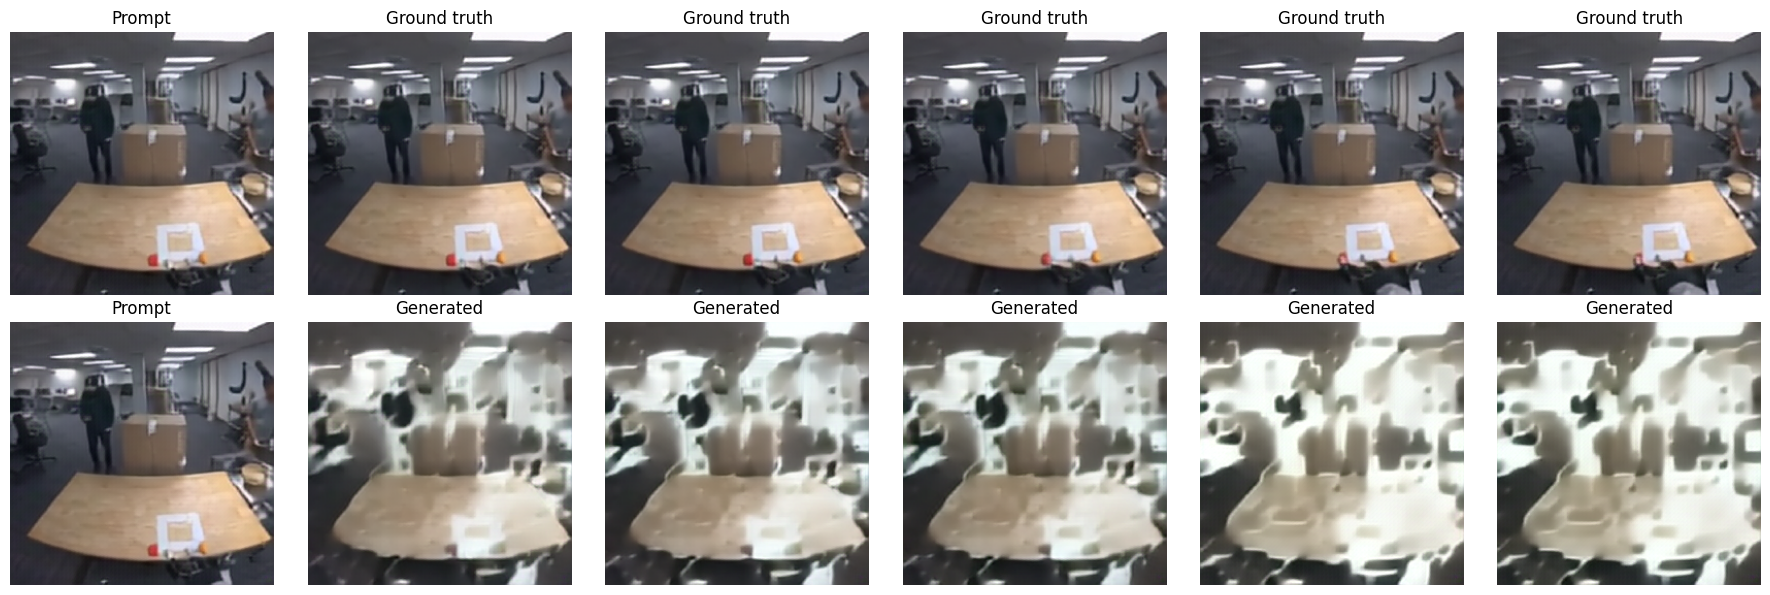

Saved input GIF: /kaggle/working/outputs/kaggle_checkpoint_inference/input_train_example6.gif
Saved prediction GIF: /kaggle/working/outputs/kaggle_checkpoint_inference/prediction_train_example6.gif
Saved comparison PNG: /kaggle/working/outputs/kaggle_checkpoint_inference/comparison_train_example6.png
Input / ground-truth video:


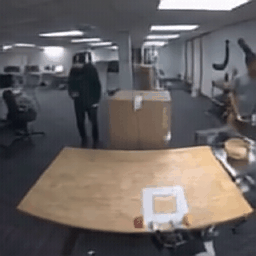

Generated prediction video:


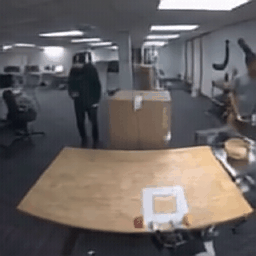

In [16]:
# Run inference on another sample without reloading the model.
# Change these values and rerun only this cell.
INFERENCE_DATA_SPLIT = "train"  # "val" or "train"
EXAMPLE_INDEX = 6
MASKGIT_STEPS = 8
TEMPERATURE = 0.0

result = run_masked_hwm_inference(
    example_index=EXAMPLE_INDEX,
    split=INFERENCE_DATA_SPLIT,
    maskgit_steps=MASKGIT_STEPS,
    temperature=TEMPERATURE,
)
